# Community Coverage & Cross-Community Mention Patterns

The Leiden community detection was run on ~131K *proactive* users, while
link prediction covers ~229K users (includes passive mentioned-only users).

**Outputs saved to** `analysis_output/E_community/`

In [ ]:
%matplotlib inline
import sys, json, re, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from IPython.display import display

SRC = Path("../src")
sys.path.insert(0, str(SRC))

from config import (RESULT_DIRS, CONDITION_LABELS, OUTPUT_DIR,
                    available_result_dirs, EVAL_K, N_RUNS)
from utils import (
    load_results_json, extract_metrics, load_past_visit_metrics_json,
    load_user_metadata, load_tweet_metadata,
    load_past_visit_preds, load_single_run_preds, load_gnn_preds,
    load_mention_rel, split_mention_rel, username_to_user_idx,
    compute_train_indegree,
)

# ── shared palette / constants ───────────────────────────────────────────────
ACTOR_ORDER = ["politician", "journalist", "scientist/academic",
               "ngo", "activist", "organization", "citizen", "inactive"]
ACTOR_COLORS = {
    "politician": "#E91E63", "journalist": "#9C27B0",
    "scientist/academic": "#3F51B5", "ngo": "#00BCD4",
    "activist": "#4CAF50", "organization": "#FF9800",
    "citizen": "#795548", "inactive": "#9E9E9E",
}
GNN_COLOR, PV_COLOR = "#FF5722", "#2196F3"

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
warnings.filterwarnings("ignore", category=FutureWarning)

print("Setup complete.  Output root:", OUTPUT_DIR)

from utils import load_community_data, load_community_types
OUT = OUTPUT_DIR / "E_community"
OUT.mkdir(parents=True, exist_ok=True)
TOP_COMMUNITIES = 15

results_tm = RESULT_DIRS["tweet_mention_orig"]
user_meta  = load_user_metadata(results_tm)
tweet_meta = load_tweet_metadata(results_tm)
print(f"user_meta: {len(user_meta):,} users  |  tweet_meta: {len(tweet_meta):,} tweets")

print("Loading community data (~119 MB) …")
comm = load_community_data()
print(f"Community CSV: {len(comm):,} users, {comm['community_id'].nunique():,} communities")


Setup complete.  Output root: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output


user_meta: 229,849 users  |  tweet_meta: 615,977 tweets
Loading community data (~119 MB) …


Community CSV: 131,205 users, 21,464 communities


## Build user–community map

In [2]:
def build_user_community_map(user_meta, comm):
    comm_slim = comm[["username","community_id","is_broker",
                       "n_authored_tweets","n_mentioned_tweets"]].copy()
    merged = (user_meta.reset_index()
              .merge(comm_slim, on="username", how="left")
              .set_index("user_idx"))
    merged["has_community"] = merged["community_id"].notna()
    return merged

ucm = build_user_community_map(user_meta, comm)
print(f"UCM: {len(ucm):,} rows  "
      f"covered={ucm['has_community'].sum():,} ({ucm['has_community'].mean():.1%})")


UCM: 229,849 rows  covered=86,540 (37.7%)


## Coverage analysis

  LP total users     : 229,849
  Covered            : 86,540  (37.7%)
  Uncovered          : 143,309  (62.3%)
  Uncovered passive  : 20,012  (14.0% of uncovered)
  Uncovered authors  : 123,297


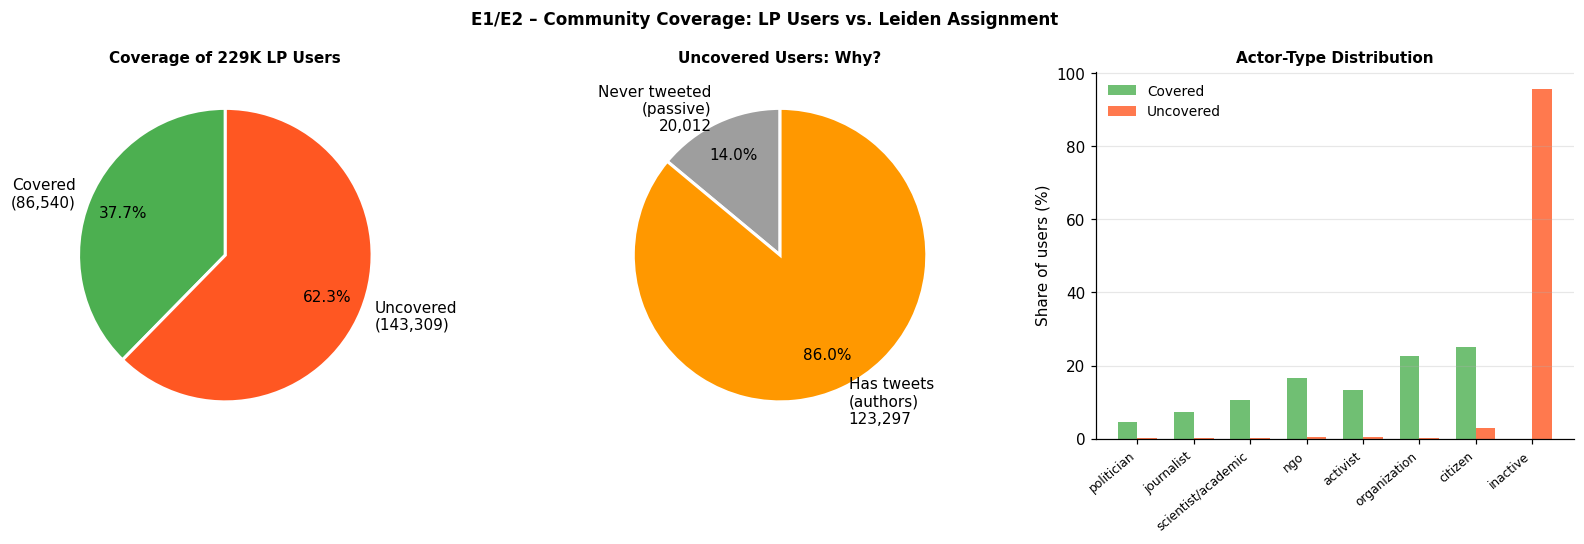

In [3]:
# Stats
n_total   = len(ucm)
n_covered = int(ucm["has_community"].sum())
n_uncov   = n_total - n_covered

covered_actors   = ucm[ucm["has_community"]]["actor_type"].value_counts(normalize=True)
uncovered_actors = ucm[~ucm["has_community"]]["actor_type"].value_counts(normalize=True)

# Who authored tweets? (active vs passive)
authors_set   = set(tweet_meta["user_idx"].unique().tolist())
uncovered_idx = ucm[~ucm["has_community"]].index.tolist()
uncov_authors = sum(1 for u in uncovered_idx if u in authors_set)
uncov_passive = len(uncovered_idx) - uncov_authors
passive_pct   = uncov_passive / len(uncovered_idx)

print(f"  LP total users     : {n_total:,}")
print(f"  Covered            : {n_covered:,}  ({n_covered/n_total:.1%})")
print(f"  Uncovered          : {n_uncov:,}  ({n_uncov/n_total:.1%})")
print(f"  Uncovered passive  : {uncov_passive:,}  ({passive_pct:.1%} of uncovered)")
print(f"  Uncovered authors  : {uncov_authors:,}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("E1/E2 – Community Coverage: LP Users vs. Leiden Assignment",
             fontsize=11, fontweight="bold")

ax = axes[0]
wedges, texts, at = ax.pie([n_covered, n_uncov],
    labels=[f"Covered\n({n_covered:,})", f"Uncovered\n({n_uncov:,})"],
    colors=["#4CAF50","#FF5722"], autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for t in at: t.set_fontsize(10)
ax.set_title("Coverage of 229K LP Users", fontsize=10, fontweight="bold")

ax = axes[1]
wedges2, texts2, at2 = ax.pie([uncov_passive, uncov_authors],
    labels=[f"Never tweeted\n(passive)\n{uncov_passive:,}",
            f"Has tweets\n(authors)\n{uncov_authors:,}"],
    colors=["#9E9E9E","#FF9800"], autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for t in at2: t.set_fontsize(10)
ax.set_title("Uncovered Users: Why?", fontsize=10, fontweight="bold")

ax = axes[2]
actor_order = ["politician","journalist","scientist/academic",
               "ngo","activist","organization","citizen","inactive"]
c_vals = [covered_actors.get(a, 0)*100 for a in actor_order]
u_vals = [uncovered_actors.get(a, 0)*100 for a in actor_order]
x, w = np.arange(len(actor_order)), 0.35
ax.bar(x - w/2, c_vals, w, label="Covered",   color="#4CAF50", alpha=0.8)
ax.bar(x + w/2, u_vals, w, label="Uncovered", color="#FF5722", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(actor_order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Share of users (%)")
ax.set_title("Actor-Type Distribution", fontsize=10, fontweight="bold")
ax.legend(fontsize=9, frameon=False); ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(OUT / "coverage_breakdown.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)


## E6 – Hypothesis setup: non-broker cross-community mentions

The earlier sections established that ~38% of test mentions cross community boundaries and that
broker users show higher cross-community rates. Here we focus on **non-broker** users who still
cross boundaries — an under-examined subgroup.

**Two competing explanations:**

**H3 – Reach-up pattern** (Granovetter 1973; Lin 2001 *Social Capital*):
Weak ties that bridge communities tend to connect to high-status, high-visibility nodes on the
other side. If H3 holds, the destination users of non-broker cross-community mentions should have
significantly higher training-period in-degree (popularity) than destinations of within-community
mentions by the same group.

**H4 – Adversarial bridging** (Bail et al. 2018 *PNAS*; Zollo et al. 2017 *PLOS ONE*):
Cross-community contact on political social media is frequently adversarial — users cross
community lines to criticise, not collaborate. If H4 holds, tweets containing non-broker
cross-community mentions should skew toward negative emotions (anger, disgust, pessimism, fear,
sadness) relative to within-community mentions by non-brokers.

## Full 2019 Scope (Proactive Users with Community)

**Scope definition (stricter than test-only):**
- **Mentions:** All 2019 mention events (`load_mention_rel()`, Jan–Dec 2019, n≈329K)
- **Source users:** Must be *proactive* (appear in community CSV — these users authored tweets and were included in Leiden community detection) AND have a valid `is_broker` label
- **Destination users:** Must also have a community assignment (required to classify cross- vs within-community)
- **Result:** Only mention pairs where both src and dst are community-covered proactive users

This is the most defensible scope for H3/H4: it tests stable structural behaviour across the full year, restricted to users whose community role is known.

Full 2019 mentions : 329,920
Date range         : 2019-01-01 → 2019-12-31
All 2019 pairs with both communities : 235,099  (71.3% of full-year mentions)
After attaching dominant_emotion     : 235,099
After filtering to proactive src     : 235,099

── Scope: Full 2019, proactive community-covered users ──
  Total pairs          : 235,099
  Unique src users     : 35,170  (broker=3,237  non-broker=31,933)
  Cross-community      : 90,455  (38.48%)
  Within-community     : 144,644  (61.52%)

Non-broker pairs (full 2019): 159,972  (cross=58,833  within=101,139)

H3 (full 2019) – Non-broker dst in-degree:
  Cross-community  : median=27  mean=273.1  n=58,833
  Within-community : median=15  mean=137.2  n=101,139
  Mann-Whitney U (cross > within): U=3434047986  p=0.0000  → H3 SUPPORTED

H4 (full 2019) – Negative emotion rate (non-broker):
  Cross-community  : 21.09%  (n=58,833)
  Within-community : 18.15%  (n=101,139)
  Δ = +2.94%
  Chi-square: χ²=206.98  p=0.0000  → H4 NOT supported


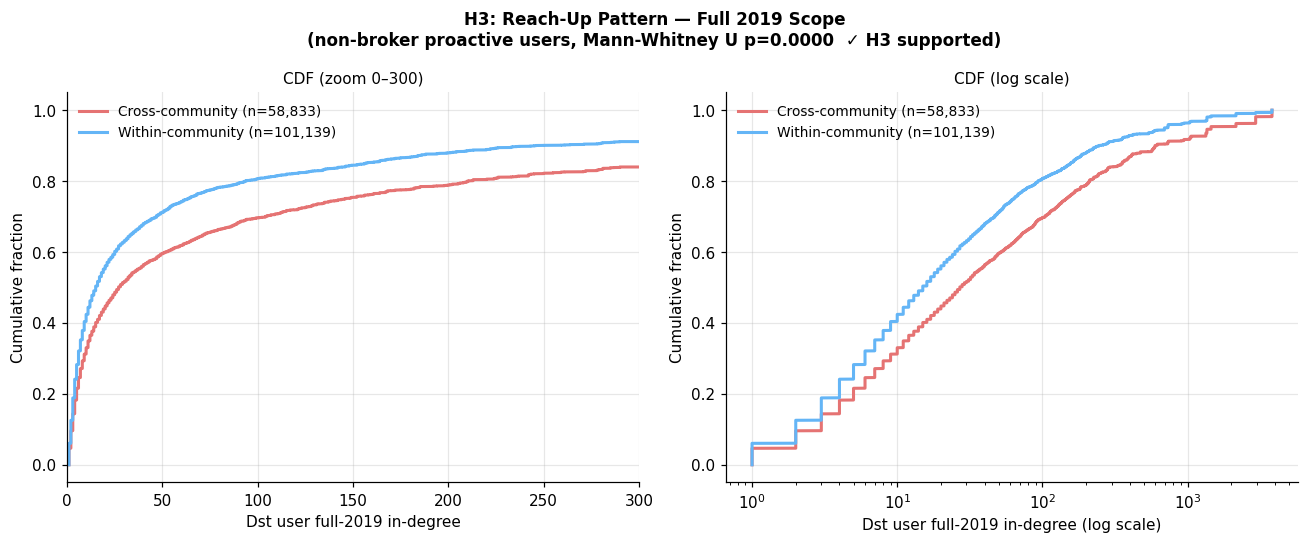

Saved: h3_reach_up_full2019.png


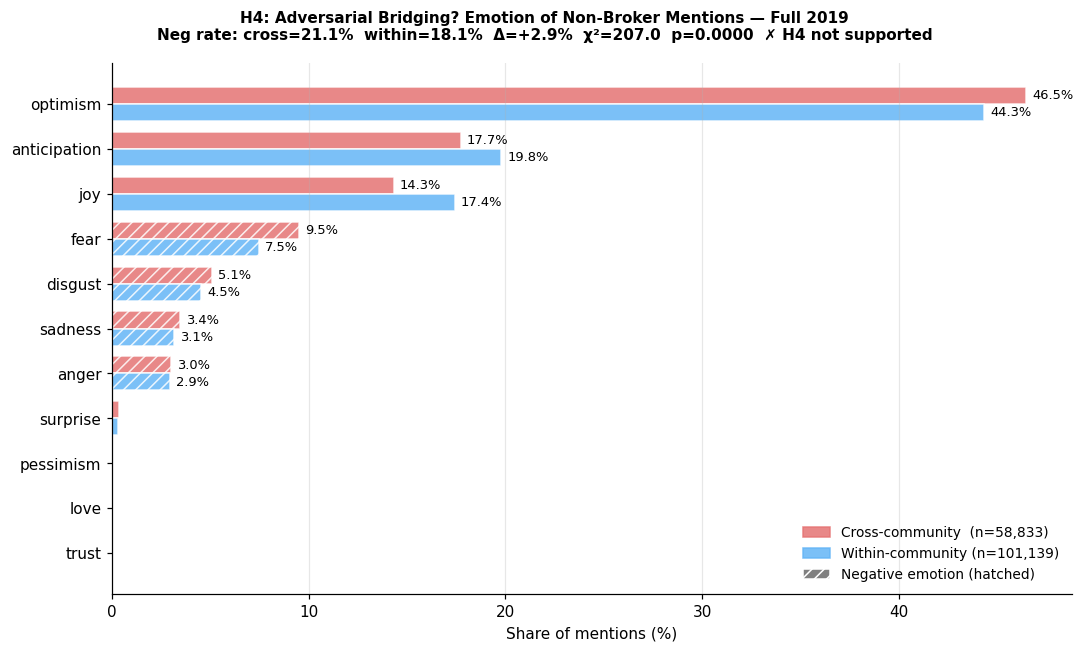

Saved: h4_adversarial_full2019.png
Saved: h3_h4_full2019_summary.csv


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, chi2_contingency

# ── 1. Load full 2019 mentions (all users, Jan–Dec 2019) ─────────────────────
mr_full = load_mention_rel()
print(f"Full 2019 mentions : {len(mr_full):,}")
print(f"Date range         : {mr_full['created_at'].min().date()} → {mr_full['created_at'].max().date()}")

# ── 2. Build mention pairs with community labels ──────────────────────────────
pairs_full = build_mention_pairs_with_community(mr_full, ucm, tweet_meta)
print(f"All 2019 pairs with both communities : {len(pairs_full):,}  "
      f"({len(pairs_full)/len(mr_full):.1%} of full-year mentions)")

# ── 3. Attach dominant_emotion from tweet_meta ───────────────────────────────
valid_tw = pairs_full["tweet_int_idx"].isin(tweet_meta.index)
pairs_full = pairs_full[valid_tw].copy()
pairs_full["dominant_emotion"] = tweet_meta.loc[pairs_full["tweet_int_idx"].values, "dominant_emotion"].values
pairs_full = pairs_full.dropna(subset=["dominant_emotion"])
print(f"After attaching dominant_emotion     : {len(pairs_full):,}")

# ── 4. Filter to proactive src users: in community CSV → has is_broker label ──
src_has_community = ucm["has_community"].reindex(pairs_full["author_user_idx"].values).fillna(False).values
pairs_full = pairs_full[src_has_community].copy()
print(f"After filtering to proactive src     : {len(pairs_full):,}")

pairs_full["is_broker_src"] = ucm["is_broker"].reindex(pairs_full["author_user_idx"].values).fillna(False).values

# ── 5. Scope summary ──────────────────────────────────────────────────────────
n_total      = len(pairs_full)
n_cross      = pairs_full["is_cross_community"].sum()
n_within     = n_total - n_cross
unique_src   = pairs_full["author_user_idx"].nunique()
unique_src_b = pairs_full[pairs_full["is_broker_src"]]["author_user_idx"].nunique()
unique_src_nb= pairs_full[~pairs_full["is_broker_src"]]["author_user_idx"].nunique()

print(f"\n── Scope: Full 2019, proactive community-covered users ──")
print(f"  Total pairs          : {n_total:,}")
print(f"  Unique src users     : {unique_src:,}  (broker={unique_src_b:,}  non-broker={unique_src_nb:,})")
print(f"  Cross-community      : {n_cross:,}  ({n_cross/n_total:.2%})")
print(f"  Within-community     : {n_within:,}  ({n_within/n_total:.2%})")

# ── 6. H3: Reach-up pattern — non-broker cross vs within dst in-degree ────────
pairs_nb_full = pairs_full[~pairs_full["is_broker_src"]].copy()
n_nb_cross    = pairs_nb_full["is_cross_community"].sum()
n_nb_within   = len(pairs_nb_full) - n_nb_cross
print(f"\nNon-broker pairs (full 2019): {len(pairs_nb_full):,}  "
      f"(cross={n_nb_cross:,}  within={n_nb_within:,})")

_mapping          = user_meta.reset_index()[["user_idx","username"]].set_index("username")["user_idx"]
_full_dst         = mr_full["user_idx"].map(_mapping).dropna().astype(int)
indegree_full2019 = _full_dst.value_counts().rename("full2019_indegree")

pairs_nb_full["dst_indegree"] = (
    indegree_full2019.reindex(pairs_nb_full["dest_user_idx"].values).fillna(0).values
)

cross_deg_f  = pairs_nb_full[pairs_nb_full["is_cross_community"]]["dst_indegree"]
within_deg_f = pairs_nb_full[~pairs_nb_full["is_cross_community"]]["dst_indegree"]

print(f"\nH3 (full 2019) – Non-broker dst in-degree:")
print(f"  Cross-community  : median={cross_deg_f.median():.0f}  mean={cross_deg_f.mean():.1f}  n={len(cross_deg_f):,}")
print(f"  Within-community : median={within_deg_f.median():.0f}  mean={within_deg_f.mean():.1f}  n={len(within_deg_f):,}")

stat_h3f, p_h3f = mannwhitneyu(cross_deg_f, within_deg_f, alternative="greater")
h3f_supported = p_h3f < 0.05
print(f"  Mann-Whitney U (cross > within): U={stat_h3f:.0f}  p={p_h3f:.4f}  "
      f"→ H3 {'SUPPORTED' if h3f_supported else 'NOT supported'}")

# ── 7. H4: Adversarial bridging — emotion of cross vs within mentions ─────────
NEGATIVE = {"anger", "disgust", "fear", "pessimism", "sadness"}
nb_e9 = pairs_nb_full.copy()
nb_e9["is_cross"]    = nb_e9["is_cross_community"]
nb_e9["is_negative"] = nb_e9["dominant_emotion"].isin(NEGATIVE)

cross_e9  = nb_e9[nb_e9["is_cross"]]
within_e9 = nb_e9[~nb_e9["is_cross"]]

neg_cross_f  = cross_e9["is_negative"].mean()
neg_within_f = within_e9["is_negative"].mean()

ct_full = pd.crosstab(
    nb_e9["is_cross"],
    nb_e9["is_negative"].map({True: "negative", False: "non-negative"})
)
chi2_f, p_h4f, _, _ = chi2_contingency(ct_full)
EFFECT_THRESHOLD = 0.05
h4f_supported = p_h4f < 0.05 and (neg_cross_f - neg_within_f) > EFFECT_THRESHOLD

print(f"\nH4 (full 2019) – Negative emotion rate (non-broker):")
print(f"  Cross-community  : {neg_cross_f:.2%}  (n={len(cross_e9):,})")
print(f"  Within-community : {neg_within_f:.2%}  (n={len(within_e9):,})")
print(f"  Δ = {(neg_cross_f - neg_within_f)*100:+.2f}%")
print(f"  Chi-square: χ²={chi2_f:.2f}  p={p_h4f:.4f}  "
      f"→ H4 {'SUPPORTED' if h4f_supported else 'NOT supported'}")

# ── 8a. Figure: H3 ───────────────────────────────────────────────────────────
fig_h3, axes_h3 = plt.subplots(1, 2, figsize=(12, 5))
h3_verdict = "✓ H3 supported" if h3f_supported else "✗ H3 not supported"
fig_h3.suptitle(
    f"H3: Reach-Up Pattern — Full 2019 Scope\n"
    f"(non-broker proactive users, Mann-Whitney U p={p_h3f:.4f}  {h3_verdict})",
    fontsize=11, fontweight="bold"
)
for ax, log_scale in zip(axes_h3, [False, True]):
    for deg, label, color in [
        (cross_deg_f,  f"Cross-community (n={len(cross_deg_f):,})",  "#E57373"),
        (within_deg_f, f"Within-community (n={len(within_deg_f):,})", "#64B5F6"),
    ]:
        arr = deg[deg > 0] if log_scale else deg
        sv  = np.sort(arr)
        cdf = np.arange(1, len(sv) + 1) / len(sv)
        ax.plot(sv, cdf, label=label, color=color, lw=2)
    if log_scale:
        ax.set_xscale("log")
        ax.set_xlabel("Dst user full-2019 in-degree (log scale)")
        ax.set_title("CDF (log scale)", fontsize=10)
    else:
        ax.set_xlim(0, 300)
        ax.set_xlabel("Dst user full-2019 in-degree")
        ax.set_title("CDF (zoom 0–300)", fontsize=10)
    ax.set_ylabel("Cumulative fraction")
    ax.legend(fontsize=9, frameon=False)
    ax.grid(alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig_h3.savefig(OUT / "h3_reach_up_full2019.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig_h3)
print("Saved: h3_reach_up_full2019.png")

# ── 8b. Figure: H4 — single grouped bar chart ────────────────────────────────
h4_verdict = "✓ H4 supported" if h4f_supported else "✗ H4 not supported"

# Build per-emotion shares for both groups, sorted by cross-community share
vc_cross  = cross_e9["dominant_emotion"].value_counts(normalize=True) * 100
vc_within = within_e9["dominant_emotion"].value_counts(normalize=True) * 100
all_emotions = sorted(set(vc_cross.index) | set(vc_within.index),
                      key=lambda e: vc_cross.get(e, 0))  # sort by cross share ascending

cross_vals  = [vc_cross.get(e, 0)  for e in all_emotions]
within_vals = [vc_within.get(e, 0) for e in all_emotions]

fig_h4, ax = plt.subplots(figsize=(10, 6))
fig_h4.suptitle(
    f"H4: Adversarial Bridging? Emotion of Non-Broker Mentions — Full 2019\n"
    f"Neg rate: cross={neg_cross_f:.1%}  within={neg_within_f:.1%}  "
    f"Δ={neg_cross_f - neg_within_f:+.1%}  χ²={chi2_f:.1f}  p={p_h4f:.4f}  {h4_verdict}",
    fontsize=10, fontweight="bold"
)

y   = np.arange(len(all_emotions))
w   = 0.38
CROSS_COLOR  = "#E57373"
WITHIN_COLOR = "#64B5F6"

bars_c = ax.barh(y + w/2, cross_vals,  w, label=f"Cross-community  (n={len(cross_e9):,})",
                 color=CROSS_COLOR,  alpha=0.85, edgecolor="white")
bars_w = ax.barh(y - w/2, within_vals, w, label=f"Within-community (n={len(within_e9):,})",
                 color=WITHIN_COLOR, alpha=0.85, edgecolor="white")

# Hatch negative-emotion bars to distinguish them
for bars, vals in [(bars_c, cross_vals), (bars_w, within_vals)]:
    for bar, emotion, val in zip(bars, all_emotions, vals):
        if emotion in NEGATIVE:
            bar.set_hatch("///")
            bar.set_edgecolor("white")
        if val > 0.5:
            ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=8.5)

ax.set_yticks(y)
ax.set_yticklabels(all_emotions, fontsize=10)
ax.set_xlabel("Share of mentions (%)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)

# Legend: cross/within + negative marker
neg_patch = mpatches.Patch(facecolor="grey", hatch="///", edgecolor="white",
                            label="Negative emotion (hatched)")
ax.legend(handles=[
    mpatches.Patch(color=CROSS_COLOR,  alpha=0.85, label=f"Cross-community  (n={len(cross_e9):,})"),
    mpatches.Patch(color=WITHIN_COLOR, alpha=0.85, label=f"Within-community (n={len(within_e9):,})"),
    neg_patch,
], fontsize=9, frameon=False, loc="lower right")

plt.tight_layout()
fig_h4.savefig(OUT / "h4_adversarial_full2019.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig_h4)
print("Saved: h4_adversarial_full2019.png")

# ── 9. Save summary CSV ──────────────────────────────────────────────────────
summary_e9 = pd.DataFrame([{
    "scope":                     "full_2019_proactive_community_users",
    "total_pairs":               n_total,
    "unique_src_users":          unique_src,
    "unique_src_broker":         unique_src_b,
    "unique_src_nonbroker":      unique_src_nb,
    "cross_community_pairs":     n_cross,
    "within_community_pairs":    n_within,
    "cross_rate":                n_cross / n_total,
    "nb_cross_pairs":            n_nb_cross,
    "nb_within_pairs":           n_nb_within,
    "h3_cross_median_indegree":  cross_deg_f.median(),
    "h3_within_median_indegree": within_deg_f.median(),
    "h3_mannwhitney_u":          stat_h3f,
    "h3_mannwhitney_p":          p_h3f,
    "h3_supported":              h3f_supported,
    "h4_neg_rate_cross":         neg_cross_f,
    "h4_neg_rate_within":        neg_within_f,
    "h4_delta_pct":              (neg_cross_f - neg_within_f) * 100,
    "h4_chi2":                   chi2_f,
    "h4_p":                      p_h4f,
    "h4_supported":              h4f_supported,
}])
summary_e9.to_csv(OUT / "h3_h4_full2019_summary.csv", index=False, float_format="%.6f")
print("Saved: h3_h4_full2019_summary.csv")

In [10]:
# ── E9 follow-up: broker vs non-broker breakdown of cross-community pairs ────
# Context: total cross-community pairs = 90,455 (all src users, broker + non-broker)
# H3 used only non-broker sources. Here we show the full breakdown.

cross_all   = pairs_full[pairs_full['is_cross_community']]
cross_nb    = cross_all[~cross_all['is_broker_src']]
cross_br    = cross_all[cross_all['is_broker_src']]

print('── Cross-community pairs (90,455 total) ──')
print(f'  Non-broker src : {len(cross_nb):,}  ({len(cross_nb)/len(cross_all):.1%})')
print(f'  Broker src     : {len(cross_br):,}  ({len(cross_br)/len(cross_all):.1%})')

print()
print('── Unique src USERS behind cross-community pairs ──')
print(f'  Non-broker users : {cross_nb["author_user_idx"].nunique():,}')
print(f'  Broker users     : {cross_br["author_user_idx"].nunique():,}')

print()
print('── Average cross-community mentions per user ──')
print(f'  Non-broker : {len(cross_nb) / cross_nb["author_user_idx"].nunique():.1f} mentions/user')
print(f'  Broker     : {len(cross_br) / cross_br["author_user_idx"].nunique():.1f} mentions/user')

print()
print('── Confirmation: H3 used src=non-broker, measured DST in-degree ──')
print(f'  cross_deg_f  = dst in-degree of {len(cross_deg_f):,} cross-community pairs (non-broker src)')
print(f'  within_deg_f = dst in-degree of {len(within_deg_f):,} within-community pairs (non-broker src)')
print(f'  Median dst in-degree — cross: {cross_deg_f.median():.0f}  within: {within_deg_f.median():.0f}')


── Cross-community pairs (90,455 total) ──
  Non-broker src : 58,833  (65.0%)
  Broker src     : 31,622  (35.0%)

── Unique src USERS behind cross-community pairs ──
  Non-broker users : 18,078
  Broker users     : 2,574

── Average cross-community mentions per user ──
  Non-broker : 3.3 mentions/user
  Broker     : 12.3 mentions/user

── Confirmation: H3 used src=non-broker, measured DST in-degree ──
  cross_deg_f  = dst in-degree of 58,833 cross-community pairs (non-broker src)
  within_deg_f = dst in-degree of 101,139 within-community pairs (non-broker src)
  Median dst in-degree — cross: 27  within: 15
